# 3D Homogeneous LL (HYPRE + Profiler)

## Notes Before Running
- Activate local environment: `source setup/activate_optimized_octave.sh`
- In Jupyter, select `Octave (local-rsb)` kernel.
- This notebook follows the COMSOL notebook structure with HYPRE + profiler instrumentation.

In [1]:
%plot -f png -r 600
% Load sparsersb for multithreaded sparse matrix-vector products
pkg load sparsersb;

% Configure toolkit for both GUI and headless Jupyter environments.
try
    graphics_toolkit('qt');
catch
    graphics_toolkit('gnuplot');
end
set(0, 'defaultfigurevisible', 'off');

fprintf('Working directory: %s\n', pwd);
fprintf('Graphics toolkit: %s\n', graphics_toolkit());


Working directory: /home/beremi/repos/slope_stability/slope_stability
Graphics toolkit: qt


## 1) Main Input Data

In [2]:
elem_type = 'P2';
Davis_type = 'B';
mat_props = [6, 45, 0, 40000, 0.3, 20, 20];
file_path = 'meshes/LL_homo_ada_L1.h5';


## 2) Reference Element Data and Mesh Load

In [3]:
[Xi, WF] = ASSEMBLY.quadrature_volume_3D(elem_type);
[HatP, DHatP1, DHatP2, DHatP3] = ASSEMBLY.local_basis_volume_3D(elem_type, Xi);

[coord, elem, surf, Q, ~] = MESH.load_mesh_P2(file_path);
[coord, elem, surf, Q] = MESH.reorder_mesh(coord, elem, surf, Q);

n_n = size(coord, 2);
n_unknown = length(coord(Q));
n_e = size(elem, 2);
n_q = length(WF);
n_int = n_e * n_q;

fprintf('\nMesh data:');
fprintf('  number of nodes =%d ', n_n);
fprintf('  number of unknowns =%d ', n_unknown);
fprintf('  number of elements =%d ', n_e);
fprintf('  number of integration points =%d ', n_int);
fprintf('\n');

material_identifier = zeros(1, n_e);


  Mesh reordering (symrcm): bandwidth 22187 -> 26247 (0.8x reduction)

Mesh data:  number of nodes =26273   number of unknowns =73459   number of elements =16813   number of integration points =184943 


### Mesh Preview

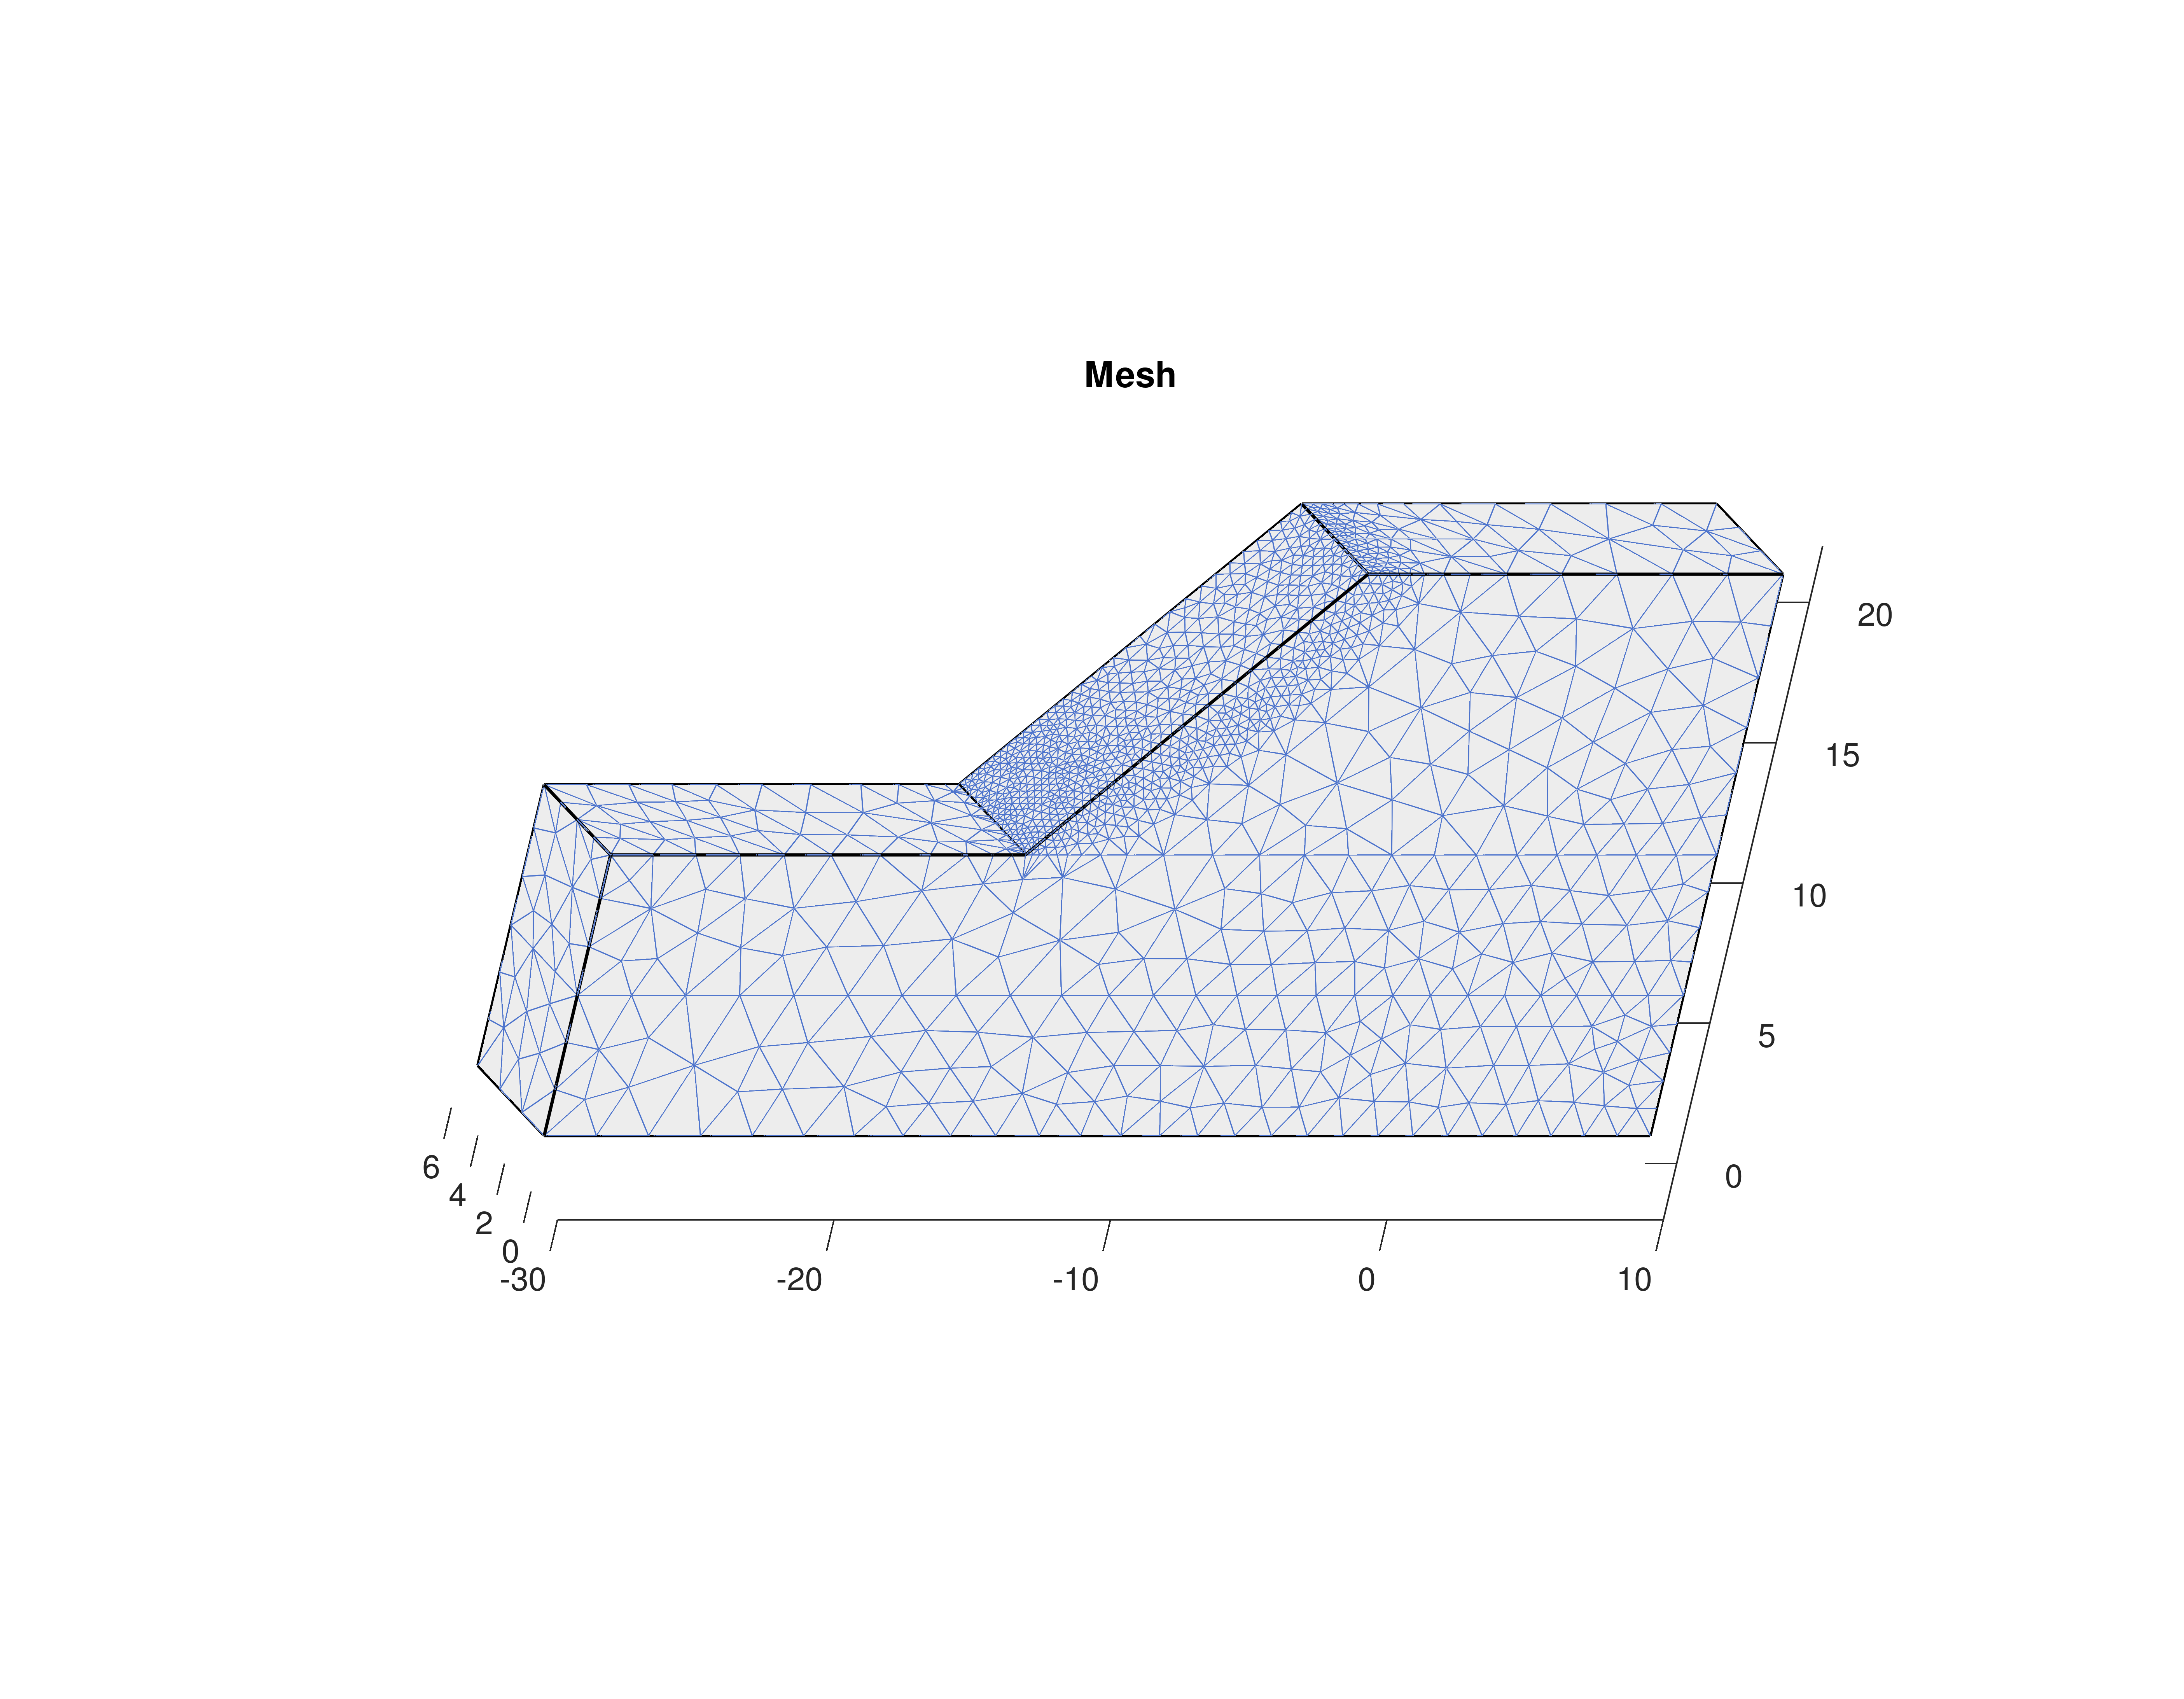

In [4]:
plotter = VIZ.SolutionPlotter(coord, elem, surf, 'comsol');
plotter.plot_mesh();
drawnow;


## 3) Mechanical Material Fields and Assembly

In [5]:
fields = {'c0', 'phi', 'psi', 'young', 'poisson', 'gamma_sat', 'gamma_unsat'};
materials = cellfun(@(x) cell2struct(num2cell(x), fields, 2), num2cell(mat_props, 2), 'UniformOutput', false);

saturation = true(1, n_int);
[c0, phi, psi, shear, bulk, lame, gamma] = ...
    ASSEMBLY.heterogenous_materials(material_identifier, saturation, n_q, materials);

[K_elast, B, WEIGHT, DPhi1_out, DPhi2_out, DPhi3_out] = ASSEMBLY.elastic_stiffness_matrix_3D(...
    elem, coord, shear, bulk, DHatP1, DHatP2, DHatP3, WF);

f_V_int = [zeros(1, n_int); -gamma; zeros(1, n_int)];
f_V = ASSEMBLY.vector_volume_3D(elem, coord, f_V_int, HatP, WEIGHT);


In [6]:
plotter.set_strain_data(B, Xi);


## 4) Continuation, Newton, and Linear Solver Parameters

In [7]:
d_t_min = 1e-3;
step_max = 100;
LL_omega_max = 5100;

it_newt_max = 200;
it_damp_max = 10;
tol = 1e-4;
r_min = 1e-4;

% agmg folder is baked into LINEAR_SOLVERS.set_linear_solver
solver_type = 'DFGMRES_HYPRE_BOOMERAMG';

linear_solver_tolerance = 1e-1;
linear_solver_maxit = 100;
deflation_basis_tolerance = 1e-3;
linear_solver_printing = 0;

boomeramg_opts = struct('threads', 16, 'print_level', 0, ...
    'use_as_preconditioner', true);

linear_system_solver = LINEAR_SOLVERS.set_linear_solver(solver_type, ...
    linear_solver_tolerance, linear_solver_maxit, deflation_basis_tolerance, ...
    linear_solver_printing, Q, coord, boomeramg_opts);

n_strain = 6;
constitutive_matrix_builder = CONSTITUTIVE_PROBLEM.CONSTITUTIVE(...
    B, c0, phi, psi, Davis_type, shear, bulk, lame, WEIGHT, n_strain, n_int, 3);

constitutive_matrix_builder.set_element_data(elem, DPhi1_out, DPhi2_out, DPhi3_out);

profiler = PROFILING.Profiler();
constitutive_matrix_builder.profiler = profiler;
linear_system_solver.profiler = profiler;


Element data set: n_p=10, n_e=16813, n_q=11, mex=1


## 5) Run LL Indirect Continuation

In [8]:
fprintf('\n Indirect continuation method for the LL method\n');
tic;

constitutive_matrix_builder.reduction(1.0);
U_elast = zeros(3, n_n);
linear_system_solver.setup_preconditioner(K_elast(Q, Q));
U_elast(Q) = linear_system_solver.solve(K_elast(Q, Q), f_V(Q));
linear_system_solver.expand_deflation_basis(U_elast(Q));
omega_el = f_V(Q)' * U_elast(Q);

d_omega_ini = omega_el / 5;
U_elast = U_elast / 5;

[U, t_hist, omega_hist, U_max_hist] = CONTINUATION.LL_indirect_continuation(...
    d_omega_ini, d_t_min, step_max, LL_omega_max, ...
    it_newt_max, it_damp_max, tol, r_min, K_elast, U_elast, Q, f_V, ...
    constitutive_matrix_builder, linear_system_solver.copy());

time_run = toc;
fprintf('Running_time = %f \n', time_run);

if ~isempty(strfind(upper(char(solver_type)), 'BOOMERAMG'))
    LINEAR_SOLVERS.hypre_boomeramg_clear();
end



 Indirect continuation method for the LL method
Step 2: omega_target=439.092, d_omega=439.092
Initialising K_r(Q,Q) sparse pattern ... done  (13.7 s, n_Q = 73459, nnz = 5588077)
Building element scatter map ... done  (1.3 s, n_local_dof=30, map_size=121 MB)
newton_ind_LL summary: status=converged, it=4, rel_resid=6.952752e-05, lin_it_total=[W:0,V:6], wall_time=30.73 s
  accepted: t=0.199668, d_t=0.199668, omega=439.092, d_omega=439.092, U_max=0.0166195
Step 3: omega_target=878.184, d_omega=439.092
newton_ind_LL summary: status=converged, it=7, rel_resid=3.563287e-05, lin_it_total=[W:0,V:16], wall_time=33.23 s
  accepted: t=0.39926, d_t=0.199591, omega=878.184, d_omega=439.092, U_max=0.0332445
Step 4: omega_target=1317.28, d_omega=439.092
newton_ind_LL summary: status=converged, it=7, rel_resid=8.926035e-05, lin_it_total=[W:1,V:21], wall_time=52.40 s
  accepted: t=0.598455, d_t=0.199195, omega=1317.28, d_omega=439.092, U_max=0.0500665
Step 5: omega_target=1756.37, d_omega=439.092
newto

## Profiler Summary

In [9]:
profiler.print_summary();



  Profiler Summary
  Time      %       Calls  Operation
  --------- ------ ------  ------------------------------
    199.71s  35.9%    531  DFGMRES.solve
    157.72s  28.3%    253  DFGMRES.update_preconditioner
     71.06s  12.8%    265  DFGMRES.A_orthogonalize
     47.20s   8.5%   1047  CONSTITUTIVE.stress
     32.76s   5.9%   1323  CONSTITUTIVE.build_F
     20.19s   3.6%     13  DFGMRES.setup_preconditioner
     15.26s   2.7%    276  CONSTITUTIVE.stress_tangent
     10.51s   1.9%    265  CONSTITUTIVE.build_K_tangent_QQ_vals
      2.31s   0.4%    519  DFGMRES.expand_deflation_basis
      0.02s   0.0%      1  CONSTITUTIVE.reduction
  --------- ------ ------  ------------------------------
    556.73s                TOTAL

  Sub-profile: DFGMRES.solve  (199.71s total, 531 calls)
  --------- ------ ------  ------------------------------
    151.91s  76.1%    273  precond_apply
     20.44s  10.2%    273  deflation_project
     15.04s   7.5%    531  init
      6.97s   3.5%    273  arnold

## 6) Mechanical Results and Convergence

Notebook workflow completed.


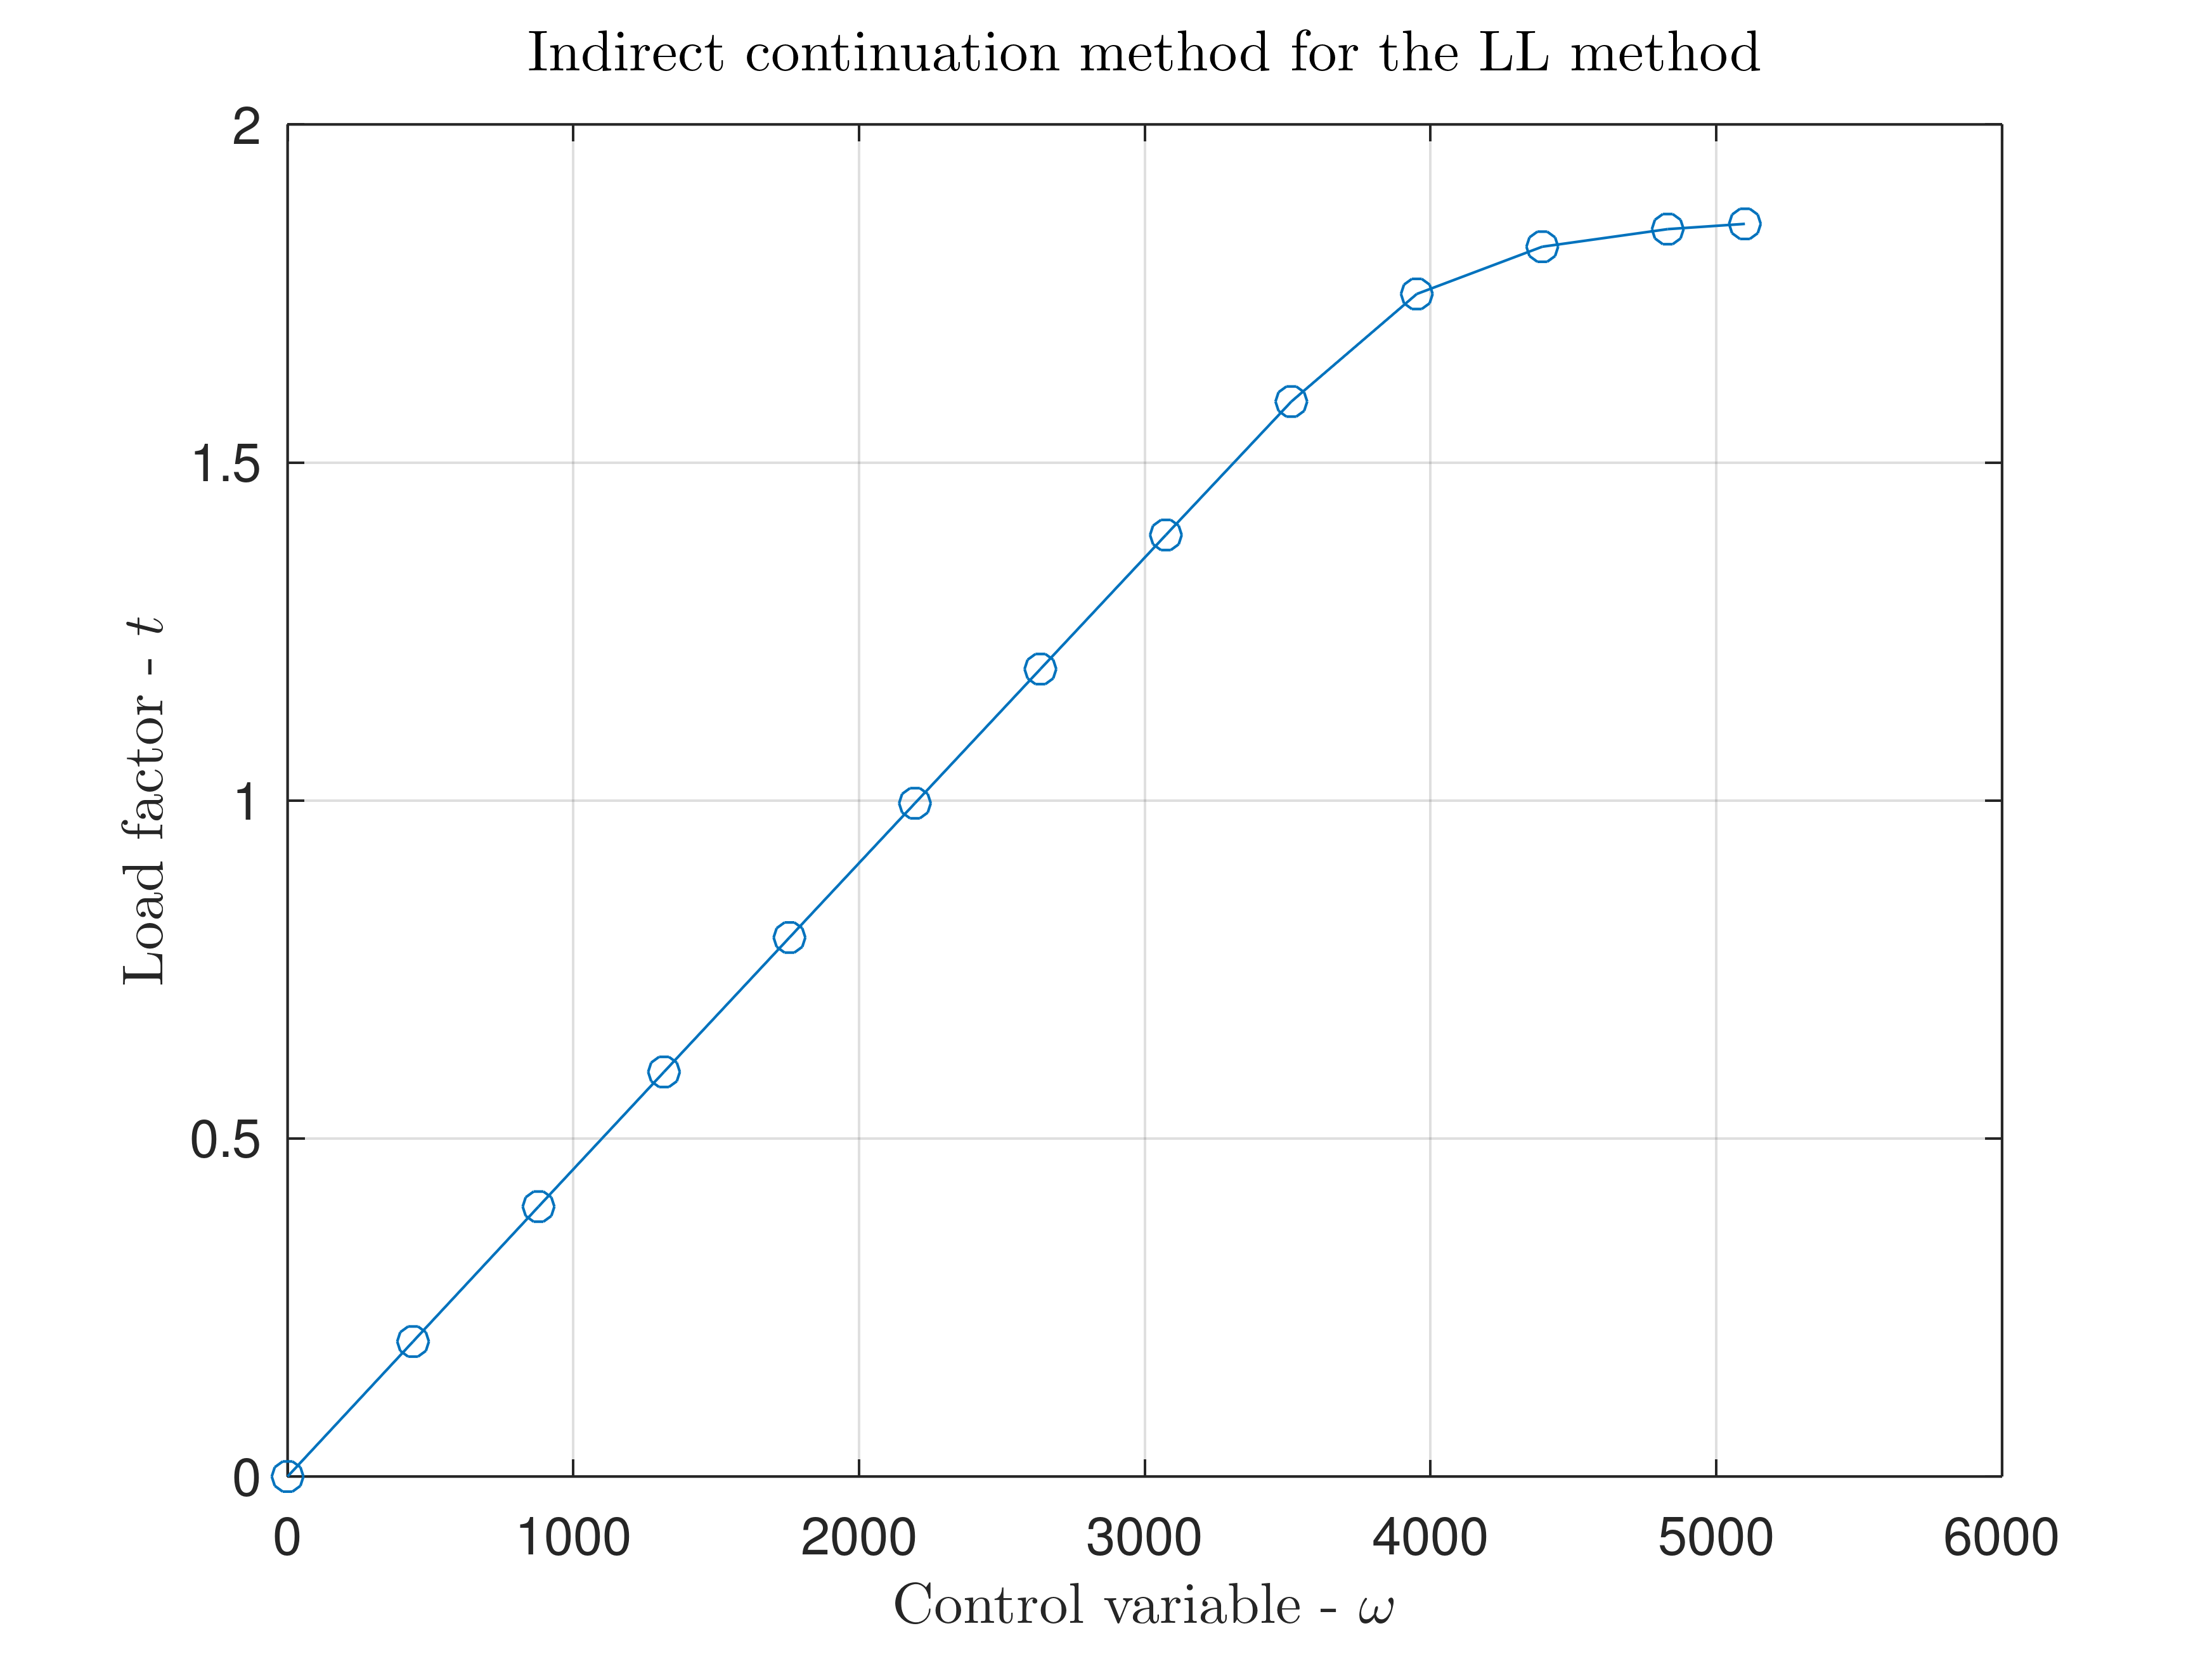

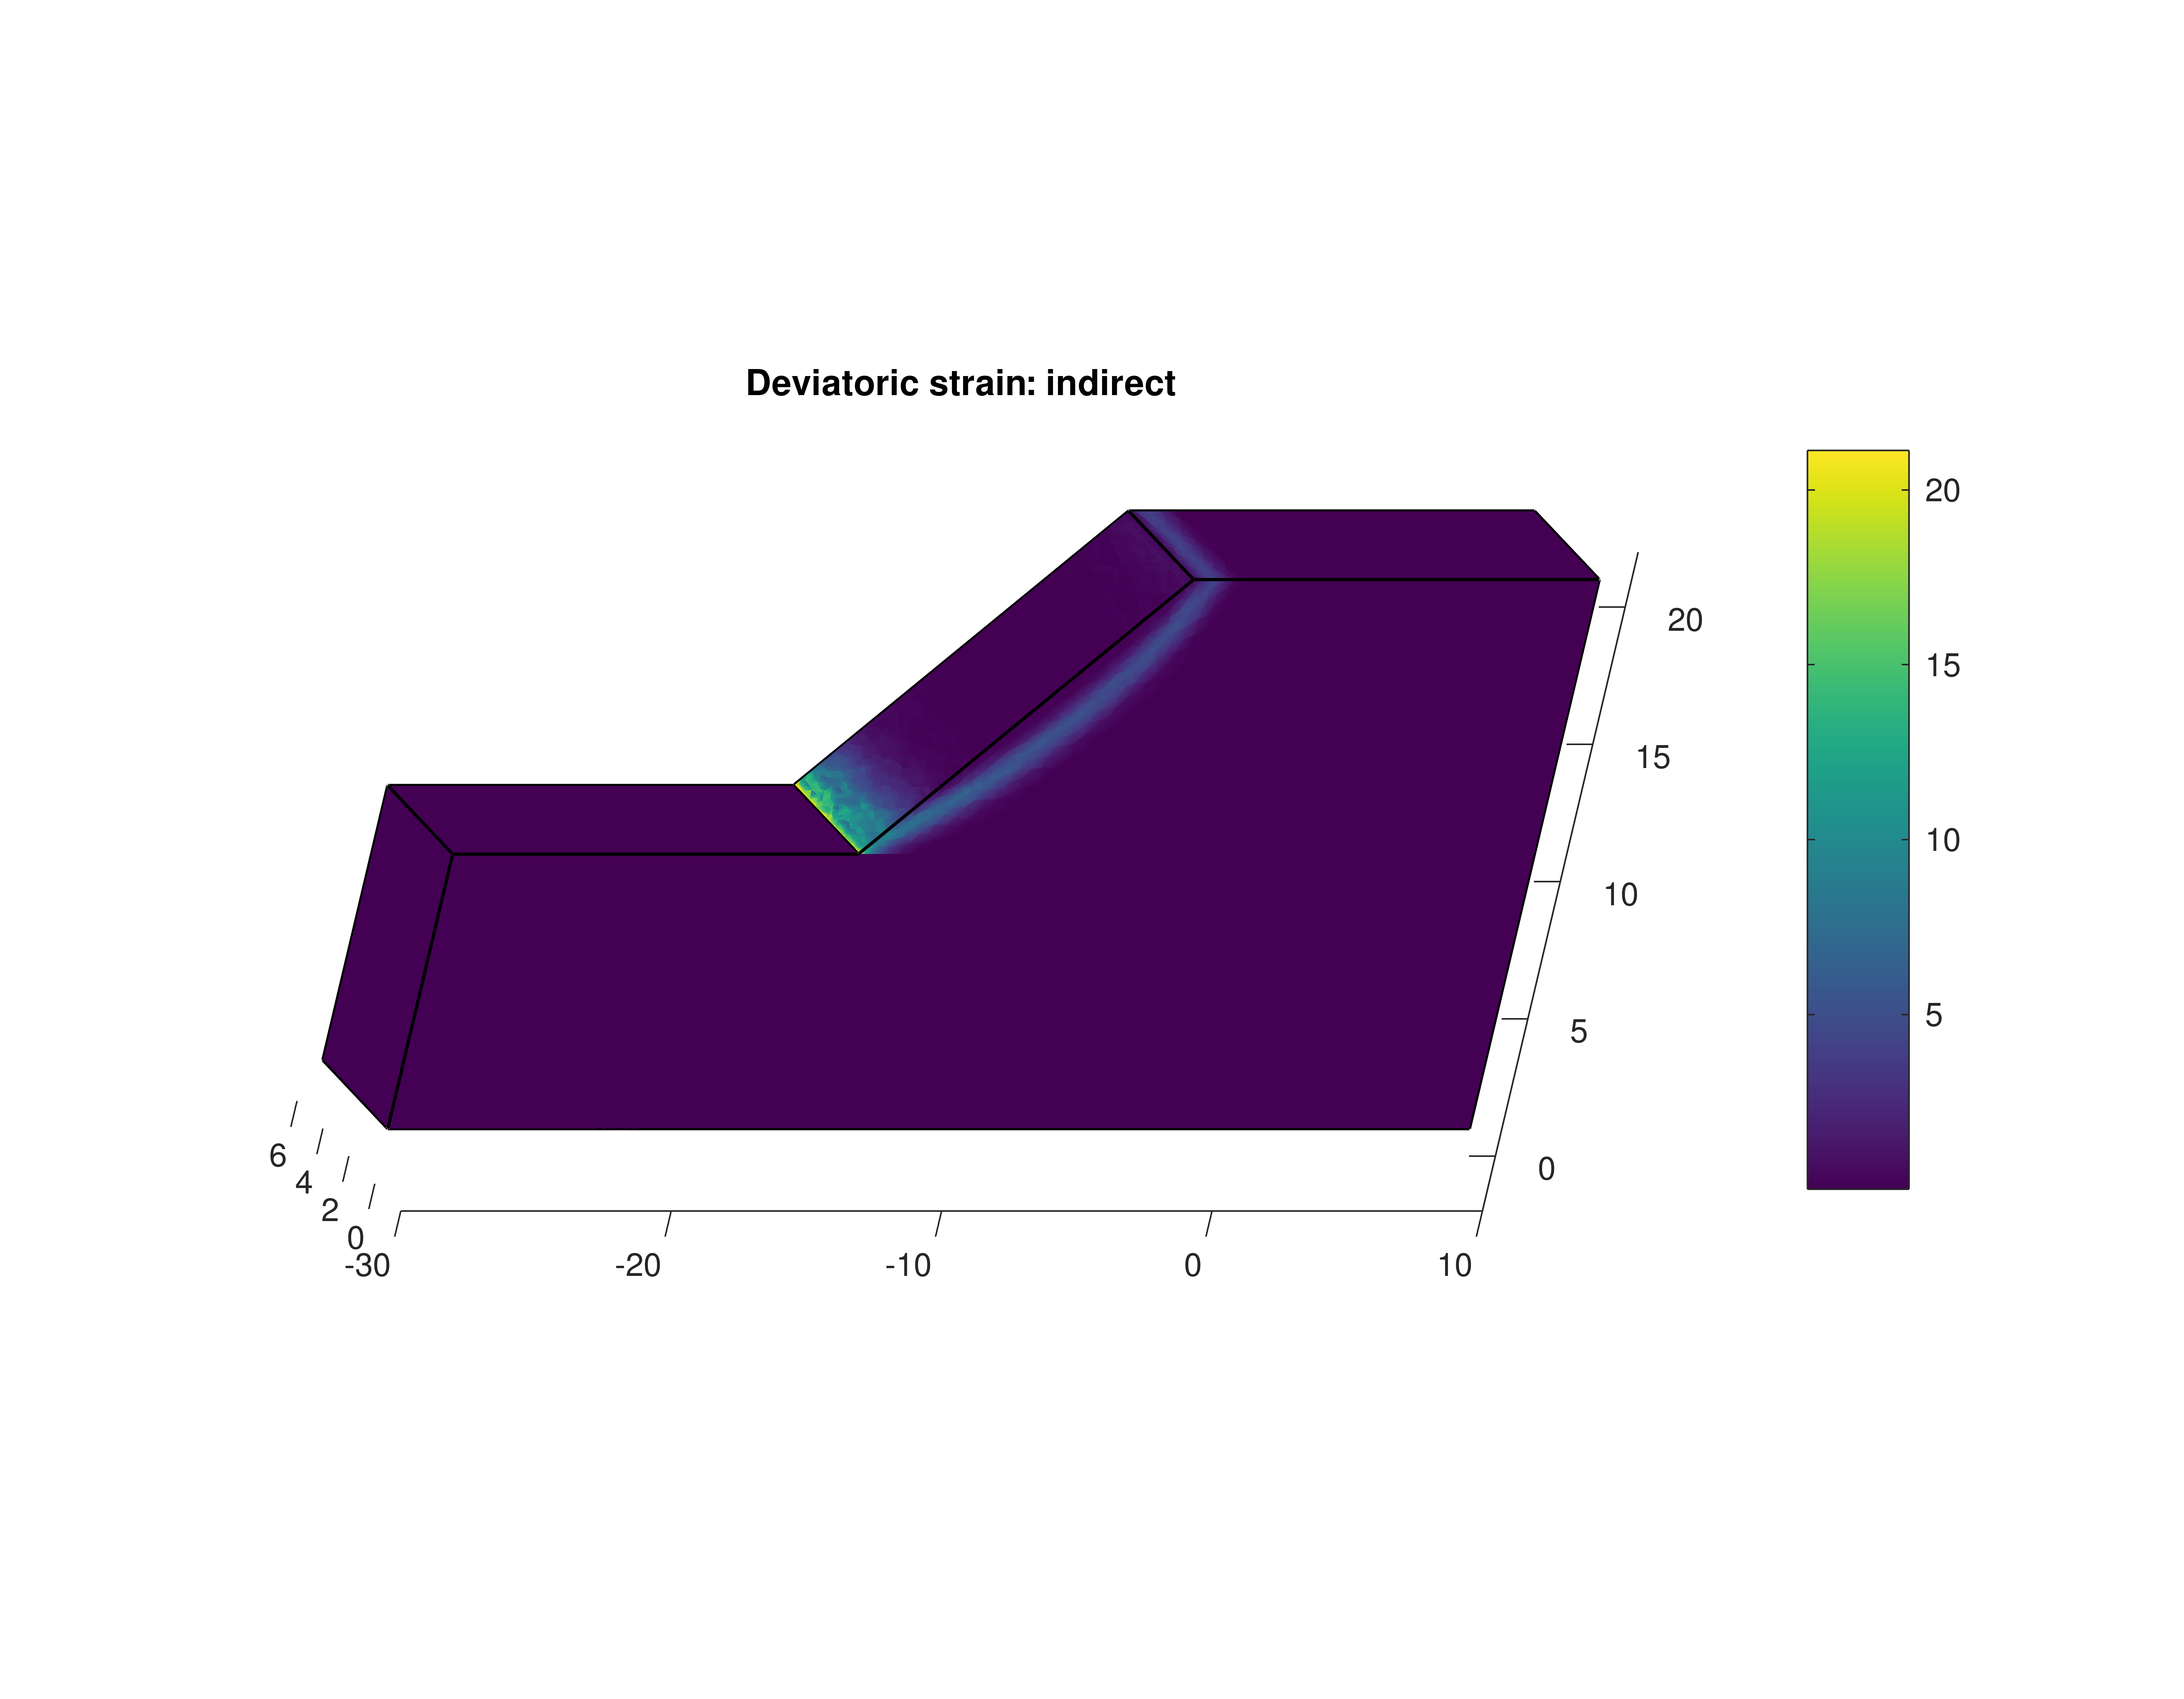

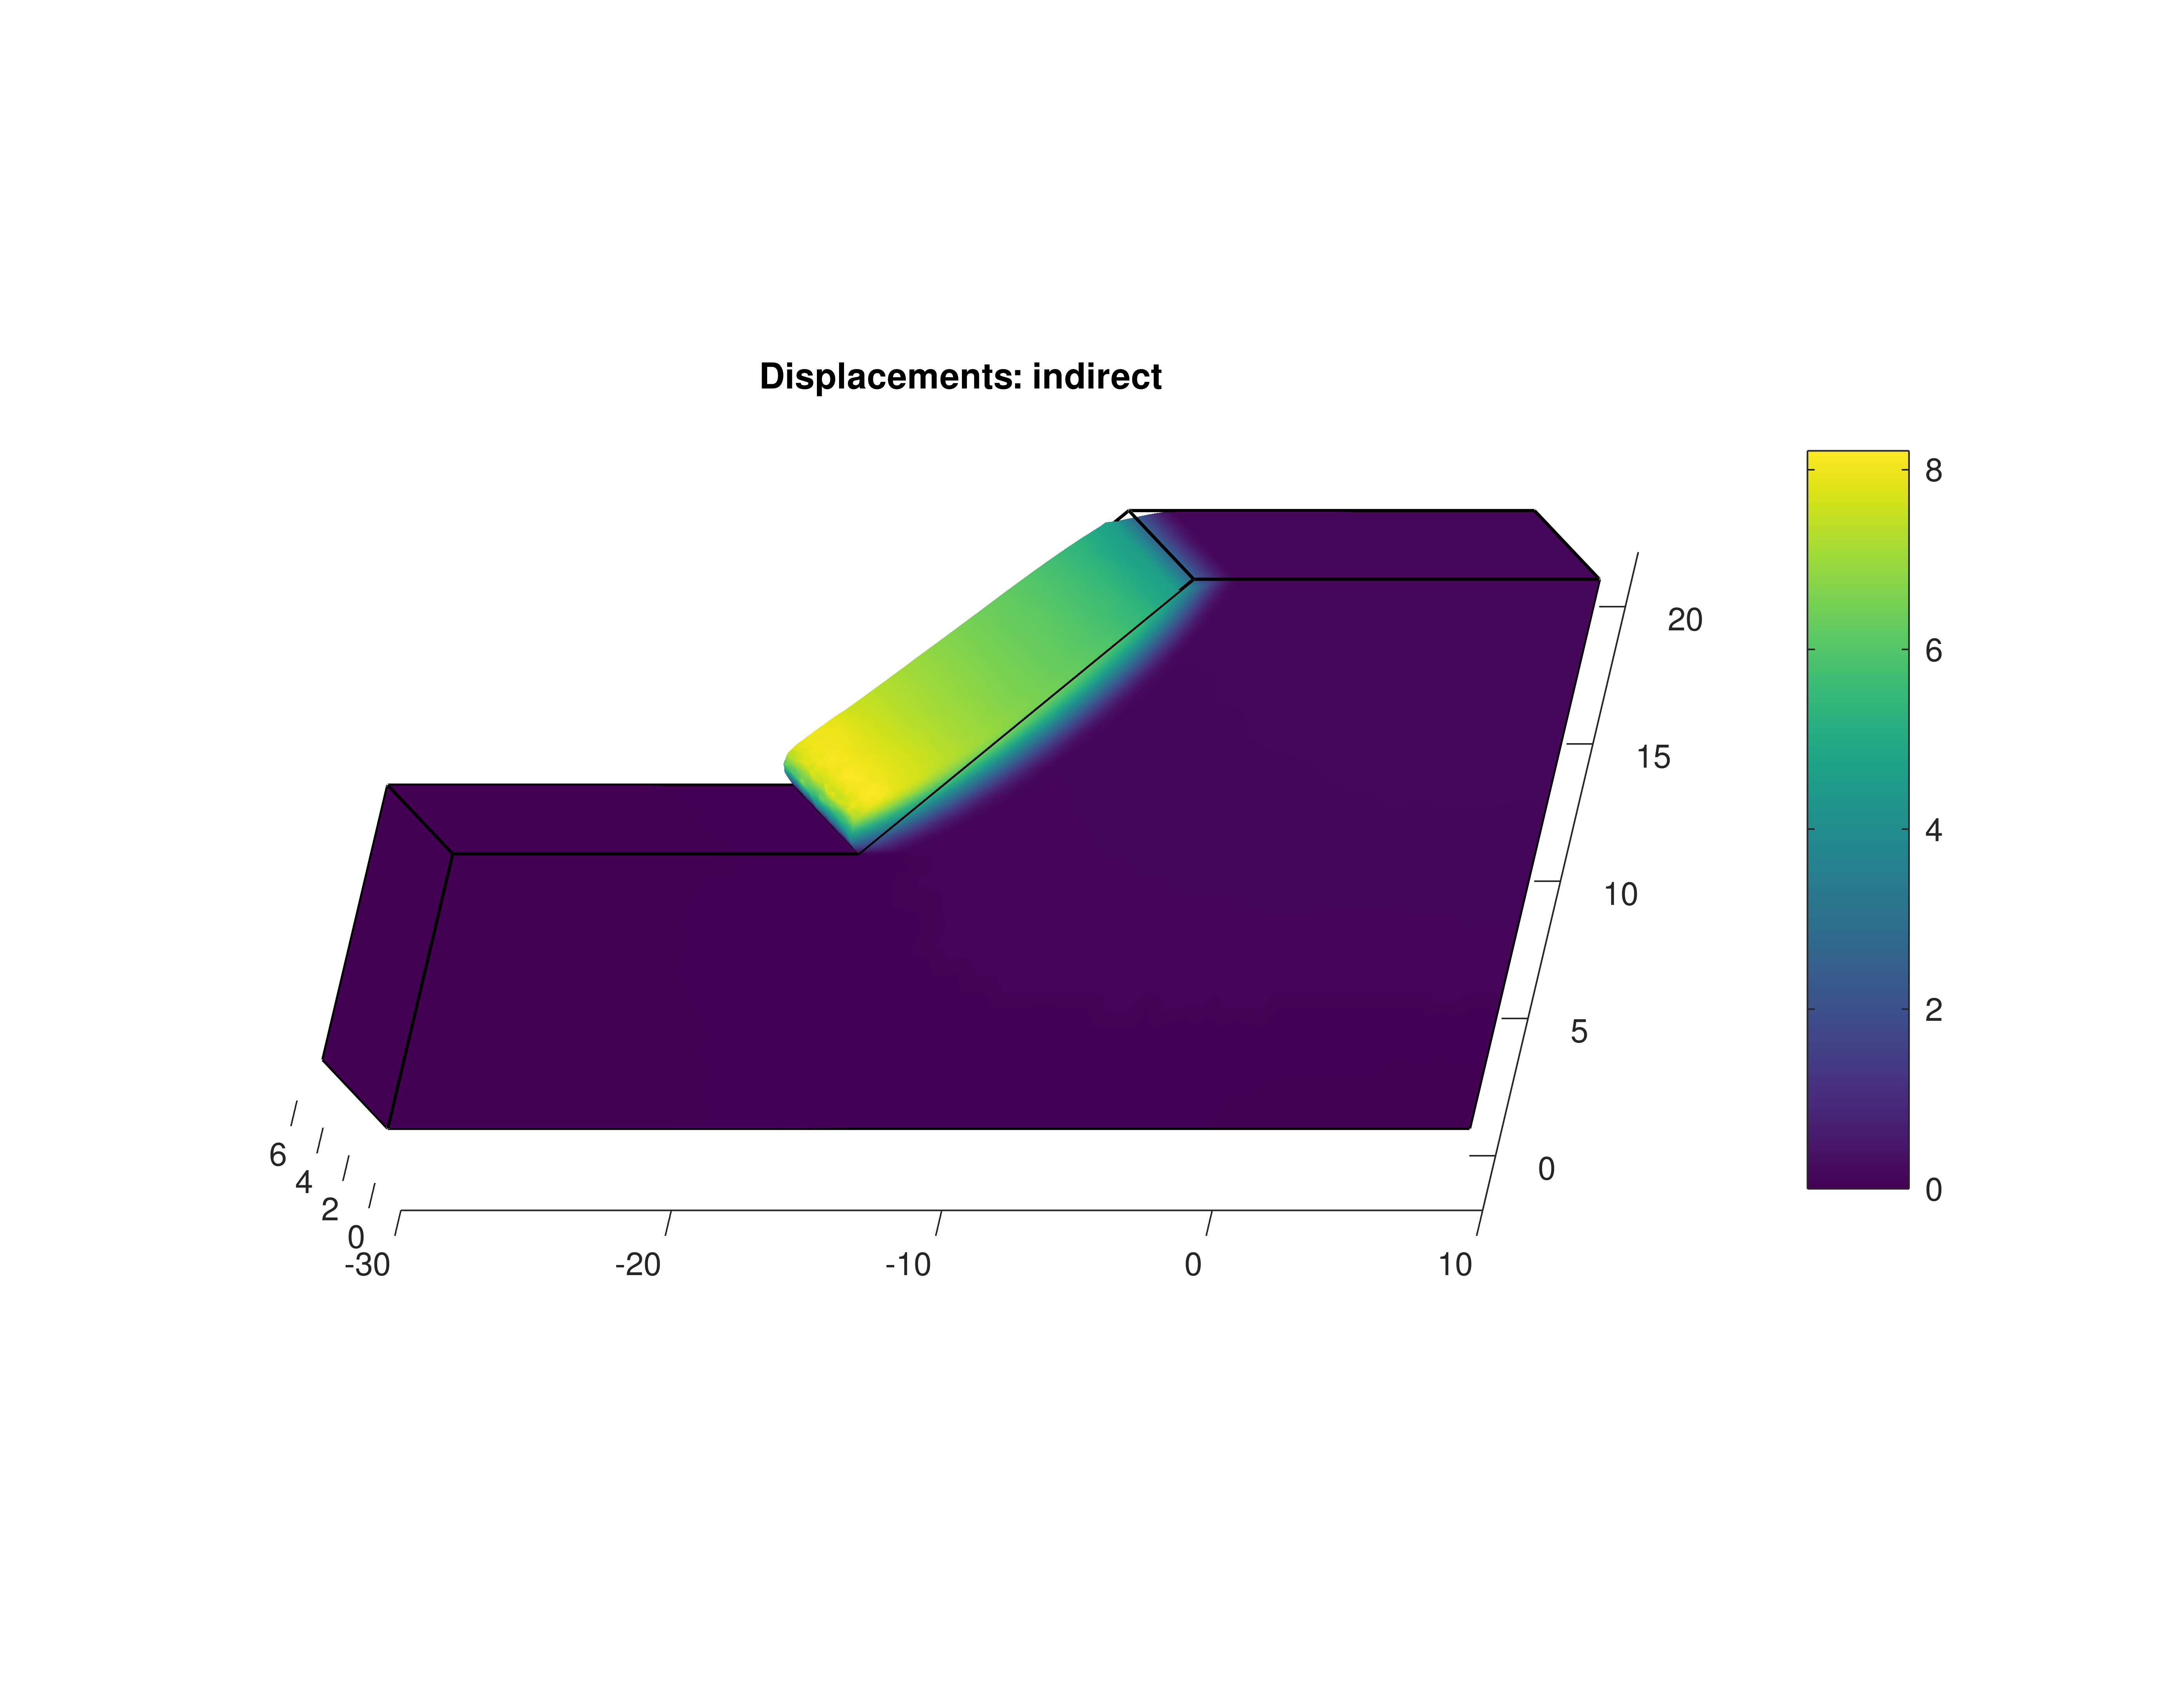

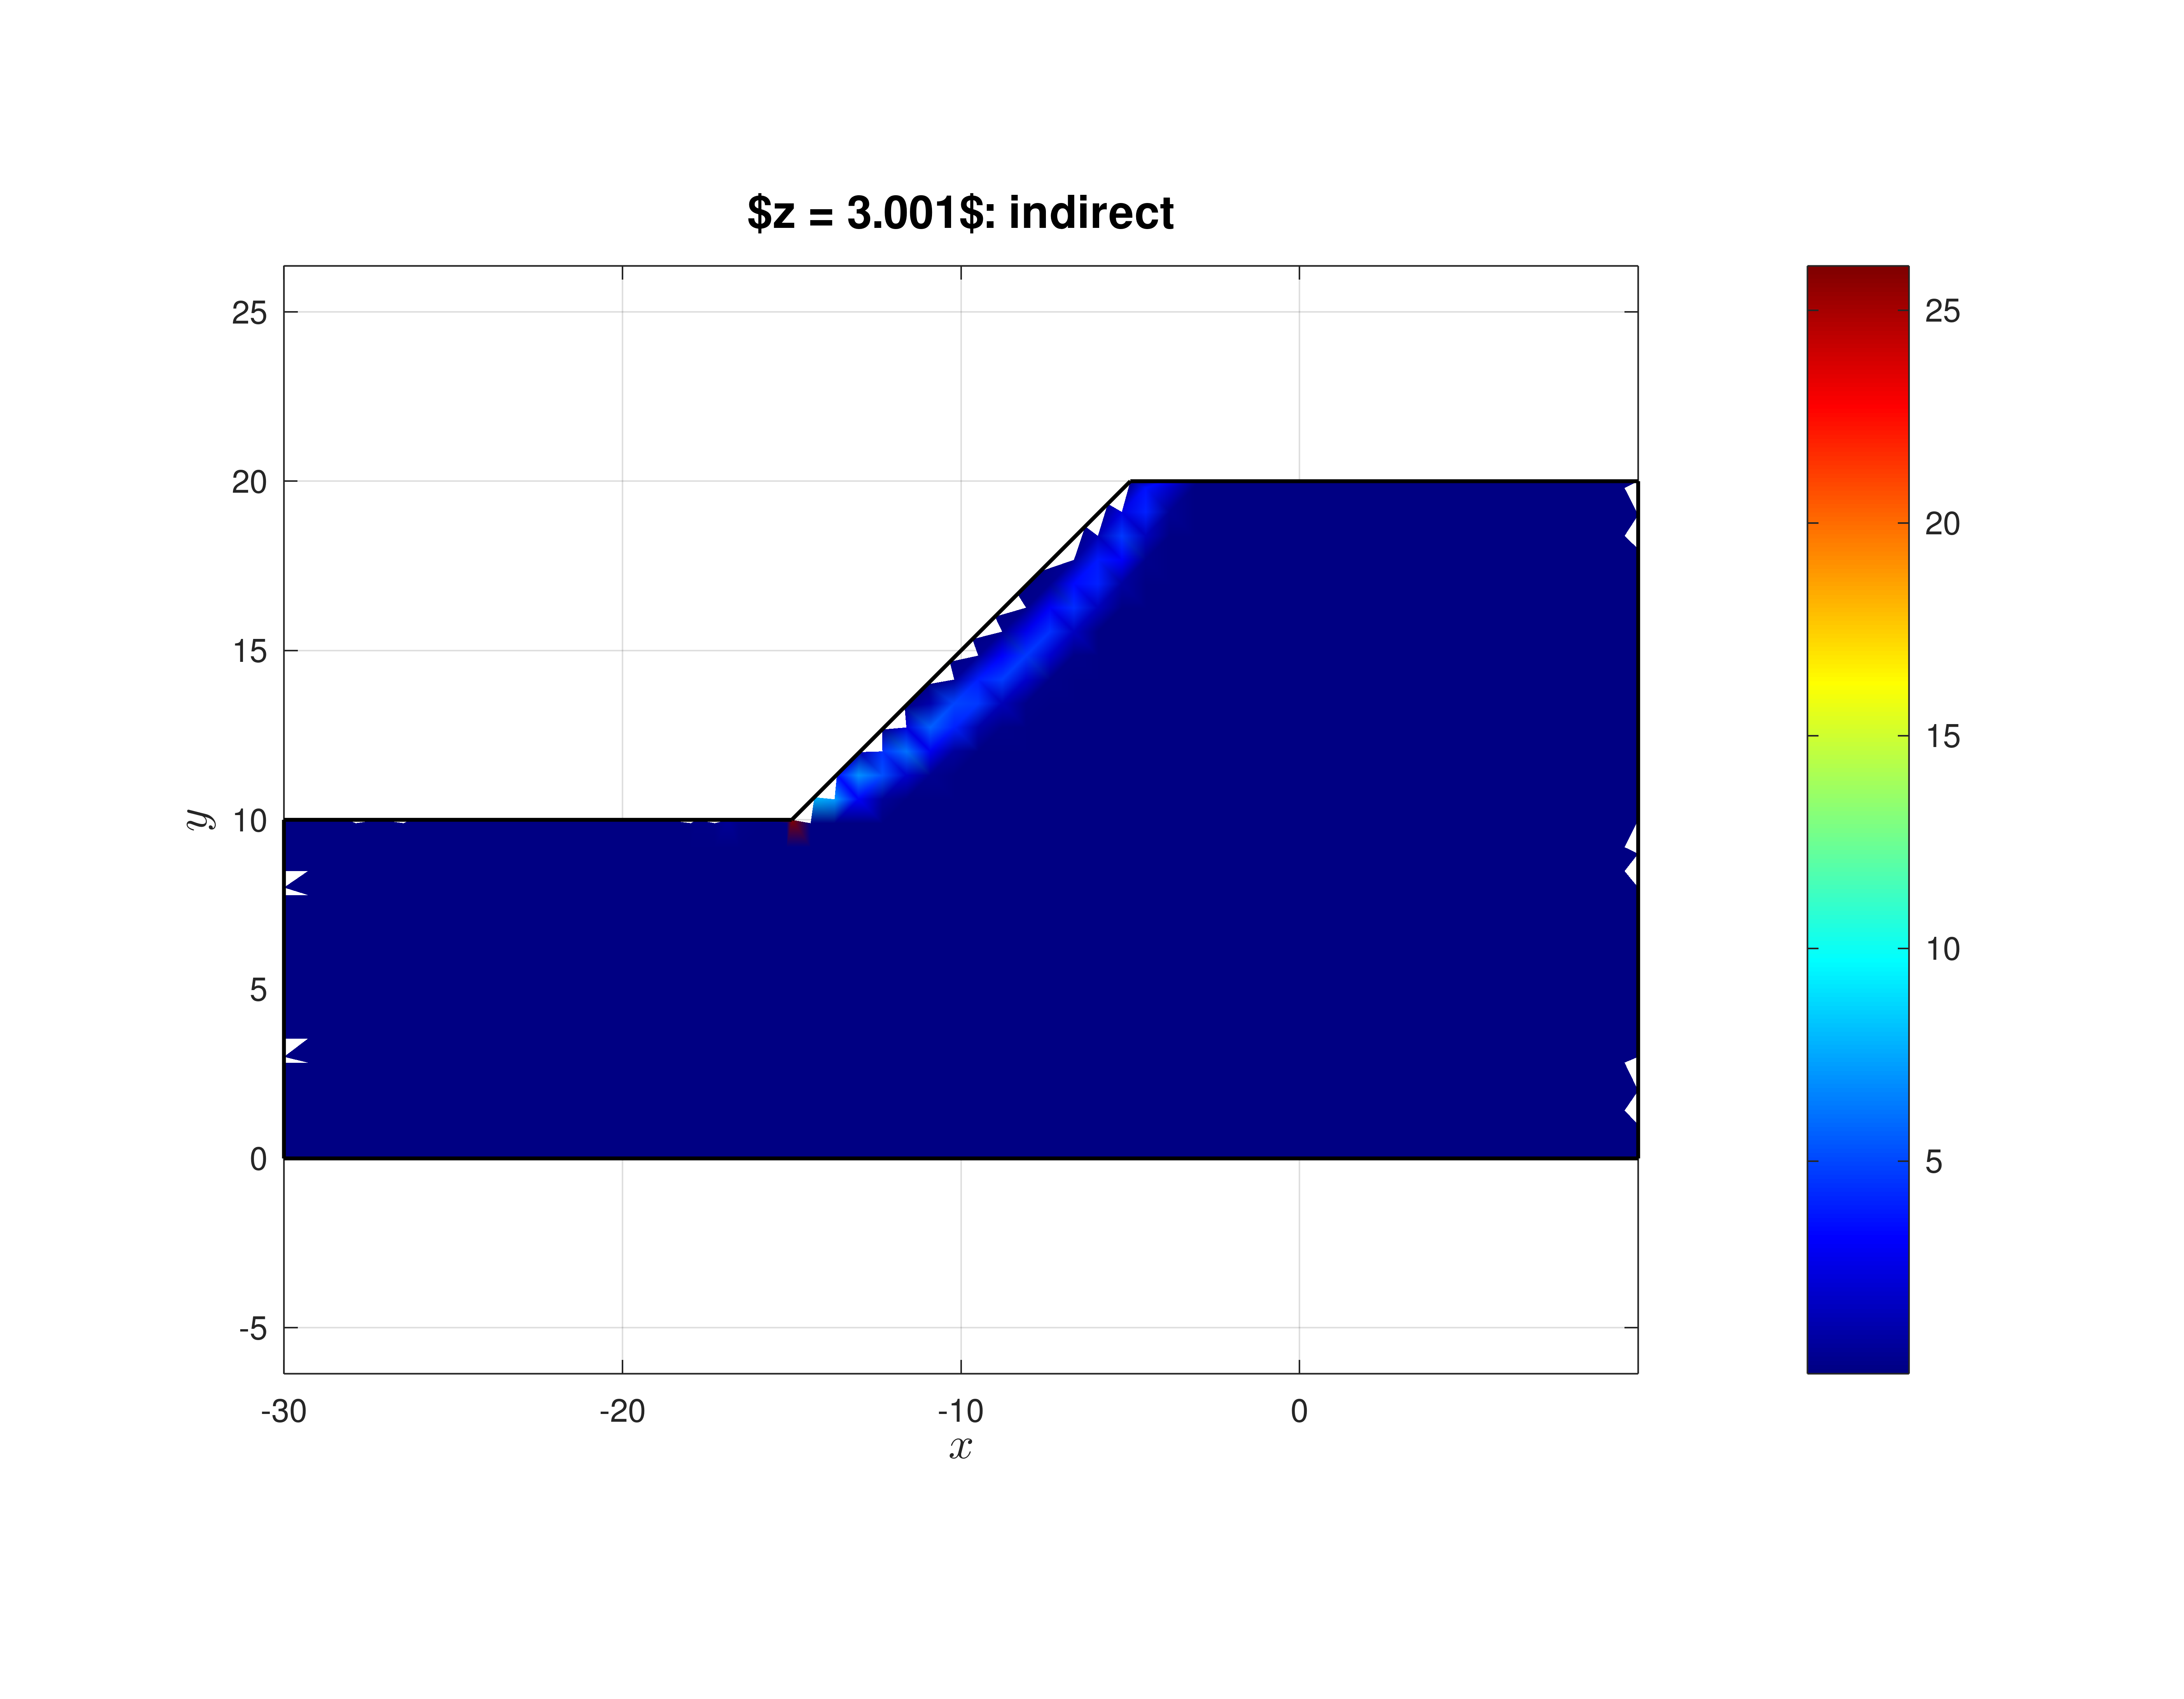

In [10]:
plotter.add_solution('indirect', U, t_hist, omega_hist, U_max_hist);

plane_vals = {[], [], [3.001]};
plotter.plot_deviatoric_slices(plane_vals, 1);
drawnow; pause(0.2);

plotter.plot_displacements();
drawnow; pause(0.2);
plotter.plot_deviatoric_strain(0.75);
drawnow; pause(0.2);

figure; hold on; box on; grid on;
plot(omega_hist, t_hist, '-o');
title('Indirect continuation method for the LL method', 'Interpreter', 'latex');
xlabel('Control variable - $\omega$', 'Interpreter', 'latex');
ylabel('Load factor - $t$', 'Interpreter', 'latex');

fprintf('Notebook workflow completed.\n');
